In [2]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['axes.facecolor'] = 'f8f9fa'
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB




# **Medical Diagnosis**
Goal: Predict medical diagnosis using biomarkers

# Part A: Data Exploration

In [3]:
#Upload Data
data2 = pd.read_csv('/content/question2_medical_diagnosis (1).csv')

# Basic exploration
print("Dataset Info:")
print(data2.info())
print("\nDataset Description:")
print(data2.describe())
print("Disease Vs. Healthy:")
print(data2['diagnosis'].value_counts(normalize=True))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              2000 non-null   int64  
 1   gender           2000 non-null   int64  
 2   family_history   2000 non-null   int64  
 3   lifestyle_score  2000 non-null   float64
 4   biomarker_1      2000 non-null   float64
 5   biomarker_2      2000 non-null   float64
 6   biomarker_3      2000 non-null   float64
 7   biomarker_4      2000 non-null   float64
 8   biomarker_5      2000 non-null   float64
 9   biomarker_6      2000 non-null   float64
 10  biomarker_7      2000 non-null   float64
 11  biomarker_8      2000 non-null   float64
 12  biomarker_9      2000 non-null   float64
 13  biomarker_10     2000 non-null   float64
 14  diagnosis        2000 non-null   int64  
dtypes: float64(11), int64(4)
memory usage: 234.5 KB
None

Dataset Description:
               ag

Data is loaded and explored above to view all features, data types, count and to gather basic stats

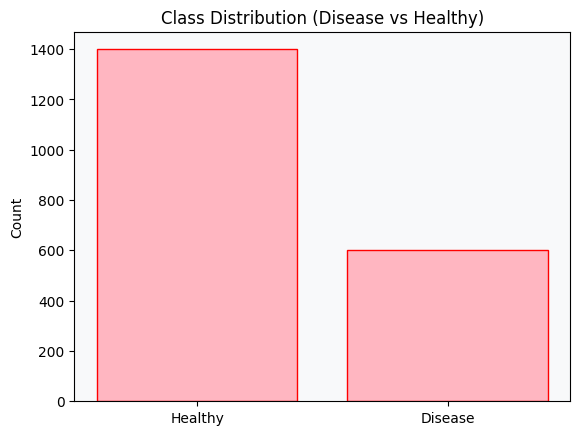

In [ ]:
#Visualize Class Distribution

counts = (data2['diagnosis'].value_counts())
plt.bar(['Healthy', 'Disease'], counts.values, color="#ffb6c1", edgecolor="red")
plt.title('Class Distribution (Disease vs Healthy)')
plt.ylabel('Count')
plt.show()

This graph shows the count for those in the dataset who are healthy vs carrying a disease.

In [ ]:
print('Biomarkers Correlation to Disease:')
corr = data2.corr(numeric_only=True)['diagnosis']
biomarker_corr = corr.filter(like='biomarker')
biomarker_corr = biomarker_corr.abs().sort_values(ascending=False)
print(biomarker_corr)


Biomarkers Correlation to Disease:
biomarker_1     0.112153
biomarker_2     0.080226
biomarker_3     0.071186
biomarker_5     0.060474
biomarker_6     0.041764
biomarker_4     0.038189
biomarker_7     0.025750
biomarker_9     0.022378
biomarker_8     0.013902
biomarker_10    0.012859
Name: diagnosis, dtype: float64


Correlation Heat Map:


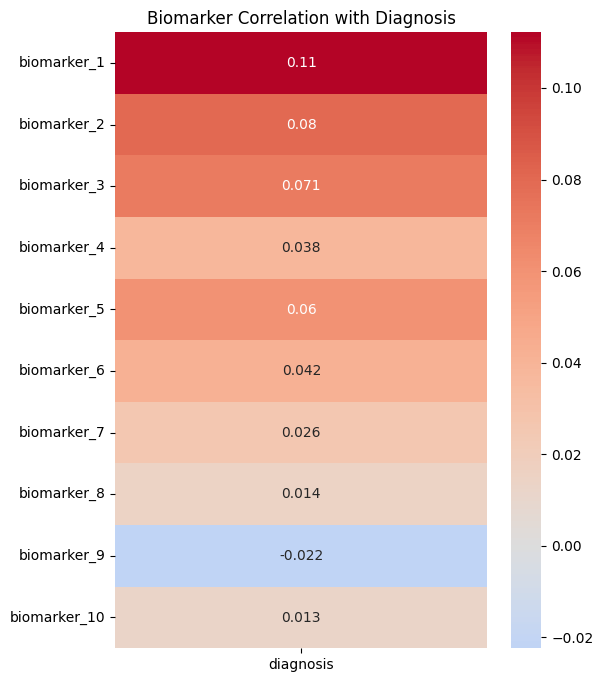

In [ ]:
print('Correlation Heat Map:')
corr = data2.corr(numeric_only=True)['diagnosis']
biomarker_corr = corr.filter(like='biomarker').to_frame()

plt.figure(figsize=(6,8))
sns.heatmap(biomarker_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Biomarker Correlation with Diagnosis')
plt.show()

This correlation indicator and heat maps shows what biomarkers are directly correlations to just a true diagnosis. As seen, biomarker_1 has the highest correlation to disease, in contract, biomarket_10 is the least correlated.

# Part B: Model Implementation

In [ ]:
# Prepare data for modeling
# Select features and target
features = ['age', 'gender', 'family_history', 'lifestyle_score', 'biomarker_1','biomarker_2', 'biomarker_3',
            'biomarker_4', 'biomarker_5', 'biomarker_6', 'biomarker_7', 'biomarker_8', 'biomarker_9', 'biomarker_10']
X = data2[features]
y = data2['diagnosis']

# Convert categorical variables into numeric
X = pd.get_dummies(X, drop_first=True)


# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Feature names: {features}")
print(f"Number of features after encoding: {X.shape[1]}")

Training set size: 1600
Test set size: 400
Feature names: ['age', 'gender', 'family_history', 'lifestyle_score', 'biomarker_1', 'biomarker_2', 'biomarker_3', 'biomarker_4', 'biomarker_5', 'biomarker_6', 'biomarker_7', 'biomarker_8', 'biomarker_9', 'biomarker_10']
Number of features after encoding: 14


First the target variable is defined (healthy vs disease) then all categorical variables are convered into numeric. The data is then split so the model can be trained. Features are then scaled to be in the same measurements, this is so difference in value measures are not drastic. Then, the training/test size, feature names and number of features are printed to verify accuracy.

**Logistic Model:**

In [ ]:
# Train Logistic Regression model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Scale the features
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model using 5-fold
print("Logistic Regression Cross-Validation Results:")

accuracy = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
precision = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='precision').mean()
recall = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='recall').mean()
f1 = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='f1').mean()

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Logistic Regression Cross-Validation Results:
Accuracy: 0.6925
Precision: 0.4557
Recall: 0.0977
F1-Score: 0.1577


This code first trains the model using the scaled data and then predictions are made on the test set. To evaluate the model; accuracy, precision, recall, F1-score and AUC-ROC were used to assess overall performance.

These results show that Logistic Regression performs relatively poorly, especially in identifying the positive class. The very low recall (9.77%) and F1-score (0.1577) indicate the model misses most true positive cases, despite moderate overall accuracy (69.25%). This suggests the model is biased toward predicting the majority class, making it ineffective for tasks like churn detection where capturing at-risk cases is critical.

**K-Nearest Neighbors (KNN:)**

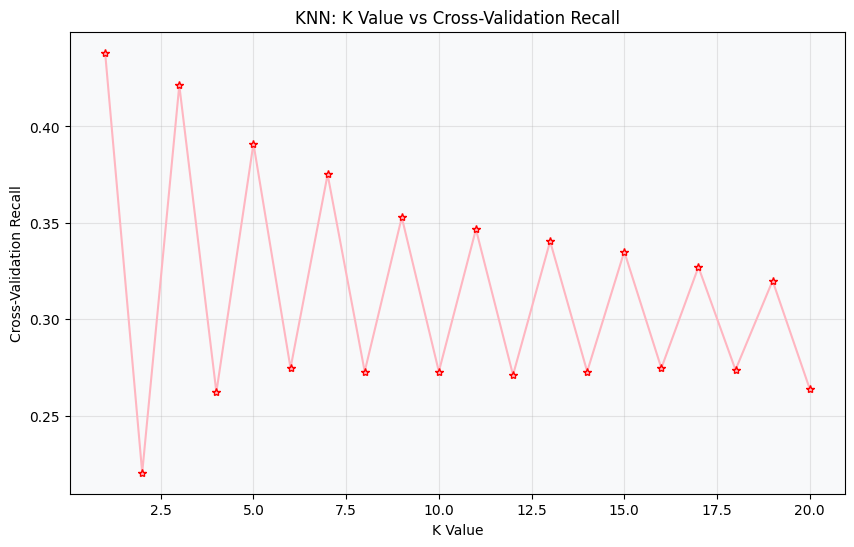

Best K value: 1
Best CV Recall: 0.4382


In [ ]:
# Find optimal k value using cross-validation
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='recall')
    cv_scores.append(scores.mean())

    # Plot k vs accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='*', color="#ffb6c1", markeredgecolor="red")
plt.title('KNN: K Value vs Cross-Validation Recall')
plt.xlabel('K Value')
plt.ylabel('Cross-Validation Recall')
plt.grid(True, alpha=0.3)
plt.show()

# Find best k
best_k = k_values[np.argmax(cv_scores)]
print(f"Best K value: {best_k}")
print(f"Best CV Recall: {max(cv_scores):.4f}")

This code tests different K-value for the KNN model using 5 fold cross validation to find the optimal number of neighbors. Then, the accuracy for each K was plotted to better visualize performance. The graph shows that model performance fluctuates across K values due to senstivity of K-value, and suggests that a more stable K would be prefered.

 A cross-validation recall of 0.4382 indicates the model correctly identifies about 43.82% of actual positive cases, which is a meaningful improvement for capturing at-risk instances. However, using k=1 can make the model more sensitive to noise and less generalizable.

In [ ]:
# Train KNN with best k
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print(f"KNN Results (k={best_k}):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_knn):.4f}")

KNN Results (k=1):
Accuracy: 0.6127
Precision: 0.4004
Recall: 0.4129
F1-Score: 0.4065
AUC-ROC: 0.5601


These results show that using k=1 improves the model’s ability to detect the target class, with recall (41.29%) much higher than before, leading to a more balanced F1-score (0.4065). However, overall accuracy drops to 61.27% and AUC is relatively low (0.5601), indicating weaker overall predictive performance. This reflects the trade-off: better at catching positives, but more sensitive to noise and less reliable overall.

**Support Vector Machine (RBF kernal):**

In [ ]:
# Train SVM with different kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    print(f"\nEvaluating SVM with {kernel} kernel using 5-fold CV...")

    svm_model = SVC(kernel=kernel, random_state=42, probability=True)

    f1_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='f1')
    accuracy_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    precision_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='precision')
    recall_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='recall')

    svm_results[kernel] = {
        'accuracy': accuracy_scores.mean(),
        'precision': precision_scores.mean(),
        'recall': recall_scores.mean(),
        'f1': f1_scores.mean()
    }

    print(f"Accuracy: {accuracy_scores.mean():.4f}")
    print(f"Precision: {precision_scores.mean():.4f}")
    print(f"Recall: {recall_scores.mean():.4f}")
    print(f"F1-Score: {f1_scores.mean():.4f}")

# Find best kernel using 5-fold

best_kernel = max(svm_results.keys(), key=lambda k: svm_results[k]['f1'])
print(f"\nBest kernel based on 5-fold CV: {best_kernel}")



Evaluating SVM with linear kernel using 5-fold CV...
Accuracy: 0.7454
Precision: 0.6575
Recall: 0.4364
F1-Score: 0.5242

Evaluating SVM with rbf kernel using 5-fold CV...
Accuracy: 0.7437
Precision: 0.6608
Recall: 0.4196
F1-Score: 0.5129

Evaluating SVM with poly kernel using 5-fold CV...
Accuracy: 0.7189
Precision: 0.6100
Recall: 0.3476
F1-Score: 0.4427

Best kernel based on 5-fold CV: linear


The SVM results show that the linear kernel performs best, achieving the highest F1-score and a good balance between precision and recall. While all models have similar accuracy, the linear kernel is more effective at identifying churn cases, making it the most suitable choice

In [ ]:
# Hyperparameter tuning for the best kernel
if best_kernel == 'rbf':
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
    }
elif best_kernel == 'linear':
    param_grid = {
        'C': [0.1, 1, 10, 100]
    }
else:  # poly
    param_grid = {
        'C': [0.1, 1, 10],
        'degree': [2, 3, 4]
    }

print(f"Tuning hyperparameters for {best_kernel} kernel...")
svm_grid = SVC(kernel=best_kernel, random_state=42, probability=True)
grid_search = GridSearchCV(svm_grid, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1-score: {grid_search.best_score_:.4f}")

# Evaluate best model
best_svm = grid_search.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)
y_pred_proba_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

print(f"\nBest SVM Test Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_svm):.4f}")

Tuning hyperparameters for linear kernel...
Best parameters: {'C': 1}
Best CV F1-score: 0.5242

Best SVM Test Results:
Accuracy: 0.7280
Precision: 0.6201
Recall: 0.3963
F1-Score: 0.4835
AUC-ROC: 0.7678


The tuned SVM model with a linear kernel shows moderate performance, with a balanced precision and recall but a slightly lower F1-score on the test set compared to cross-validation. While the AUC-ROC is relatively strong, the lower recall suggests the model still misses a number of churn cases.

**Decision Tree:**

In [ ]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)  # Note: No scaling needed for decision trees

# Make predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluate the model using 5-fold cross validation
print("Decision Tree Cross-Validation Results:")

accuracy = cross_val_score(dt_model, X, y, cv=5, scoring='accuracy').mean()
precision = cross_val_score(dt_model, X, y, cv=5, scoring='precision').mean()
recall = cross_val_score(dt_model, X, y, cv=5, scoring='recall').mean()
f1 = cross_val_score(dt_model, X, y, cv=5, scoring='f1').mean()

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Decision Tree Cross-Validation Results:
Accuracy: 0.7466
Precision: 0.6405
Recall: 0.4823
F1-Score: 0.5491


These cross-validation results show the Decision Tree performs consistently well, with strong accuracy (74.66%) and the highest F1-score (0.5491), indicating a solid balance between precision and recall. The recall of 48.23% suggests it captures nearly half of the positive cases, making it effective for identifying at-risk instances

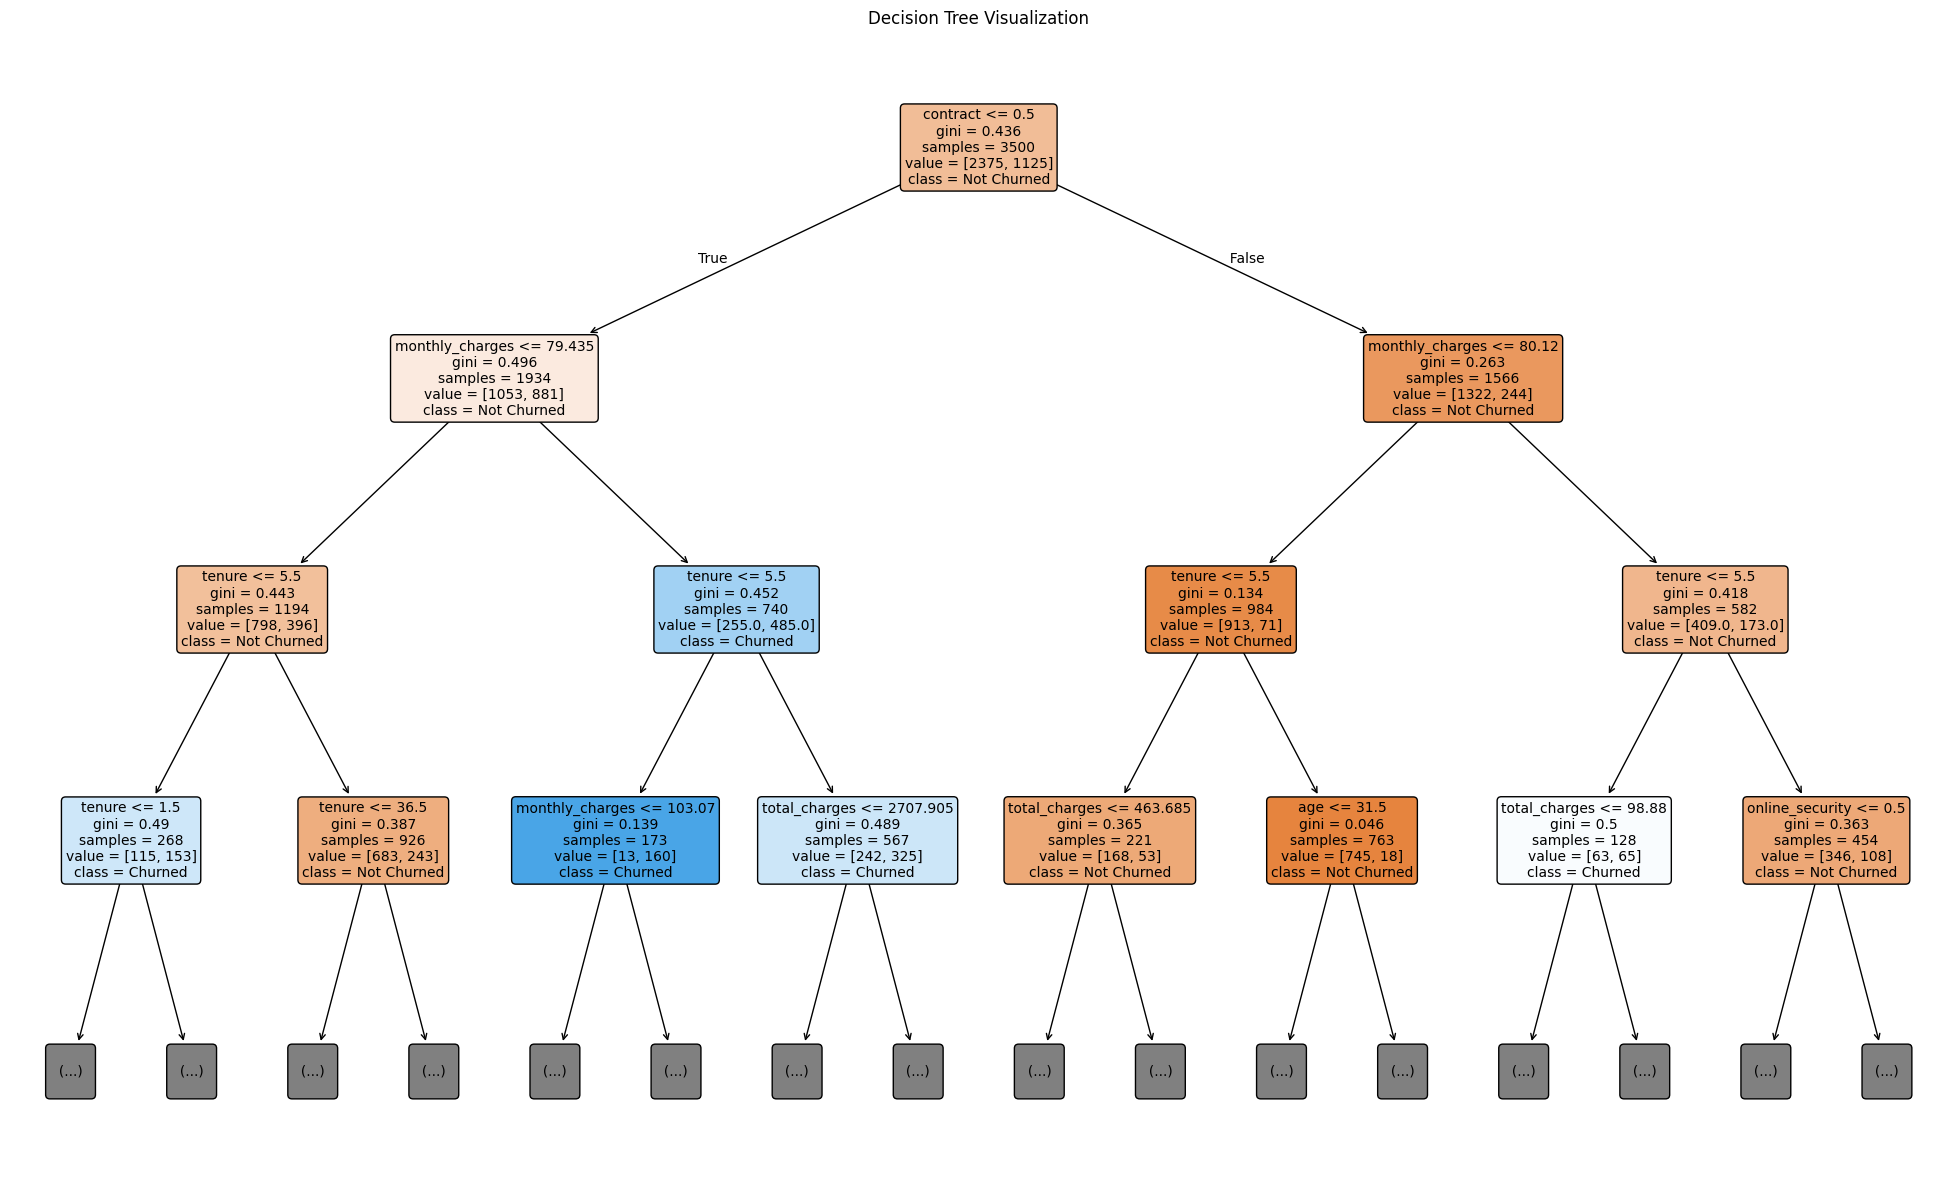

In [ ]:
plt.figure(figsize=(25, 15))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['Not Churned', 'Churned'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)
plt.title('Decision Tree Visualization')
plt.show()

5-Fold Comparision across all models:

In [ ]:
comparison_results = []

lr_f1 = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='recall').mean()
knn_f1 = cross_val_score(knn_model, X_train_scaled, y_train, cv=5, scoring='recall').mean()
svm_f1 = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='recall').mean()
dt_f1 = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='recall').mean()

comparison_results = [
    {'Model': 'Logistic Regression', 'Recall': lr_f1},
    {'Model': 'KNN', 'Recall': knn_f1},
    {'Model': 'SVM', 'Recall': svm_f1},
    {'Model': 'Decision Tree', 'Recall': dt_f1}
]

comparison_df = pd.DataFrame(comparison_results)
print("5-Fold CV Model Comparison:")
print(comparison_df.sort_values(by='Recall', ascending=False).round(4))

5-Fold CV Model Comparison:
                 Model  Recall
3        Decision Tree  0.5431
0  Logistic Regression  0.4631
1                  KNN  0.4382
2                  SVM  0.3476


This code compares models using 5-fold cross-validation with recall as the evaluation metric. The results show that the Decision Tree has the highest recall, making it the most effective at capturing at-risk customers, while SVM performs the worst in a positive diagnosis.

# **Part C: Medical Insights**

1. The model that achieves the highest sensitivity (recall) based off 5-fold cross validation is the decision tree. This model had a recall score of roughly 54%, indicating that it correctly identifies 54% of patients who actually had a disease. This implies that 46% of patients who had disease were missed (false negatives). This is a slight limitation in medical diagnosis context.

2. In medical context, a higher sensitivity is more preferred over specificity to ensure that positive/diseased cases are correctly identified. A high specificty score shows that the model is effective at correctly identifying healthy patients. The sensitivty score shows what the model misses in patients that do have disease. It is recommended to prioritze higher sensitivity, even if it means loss of specificty. This is because reducing the risk of a missed diagnosis and confirming positive cases is more important.

3. The biomarkets that are most predicitve are 1, 2 and 3. The biomarkers had the highest impact on a positive diagnosis.

In [ ]:
print(biomarker_corr.head(3))

             diagnosis
biomarker_1   0.112153
biomarker_2   0.080226
biomarker_3   0.071186
